In [3]:

!pip install transformers torch sentencepiece -q


In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModel, AutoModelForMaskedLM
from torch.utils.data import Dataset, DataLoader

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
 
# --- Protein encoder ---
prot_tokenizer = AutoTokenizer.from_pretrained("facebook/esm2_t33_650M_UR50D")
prot_encoder   = AutoModel.from_pretrained("facebook/esm2_t33_650M_UR50D").to(device)
for p in prot_encoder.parameters():
    p.requires_grad = False
prot_encoder.eval()
 
# --- Nucleotide encoder (we only use its embeddings + encoder, frozen) ---
nuc_tokenizer = AutoTokenizer.from_pretrained(
    "InstaDeepAI/nucleotide-transformer-500m-human-ref"
)
nuc_encoder = AutoModelForMaskedLM.from_pretrained(
    "InstaDeepAI/nucleotide-transformer-500m-human-ref"
).to(device)
for p in nuc_encoder.parameters():
    p.requires_grad = False
nuc_encoder.eval()
 
PROT_DIM = 1280   # ESM2 hidden size
NUC_DIM  = 1280   # NucleotideTransformer hidden size   
MASK_TOKEN_ID = nuc_tokenizer.mask_token_id
print(f"MASK token id: {MASK_TOKEN_ID}")  #the id of the[MASK] token

config.json:   0%|          | 0.00/724 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/95.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/93.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.61G [00:00<?, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/1.94G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

EsmForMaskedLM LOAD REPORT from: InstaDeepAI/nucleotide-transformer-500m-human-ref
Key                         | Status     |  | 
----------------------------+------------+--+-
esm.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/1.94G [00:00<?, ?B/s]

MASK token id: 2


In [6]:
print(nuc_tokenizer.vocab_size)  #which are???

4107


### Why 4107 instead of 4 (A,U,G,C)
The model isnt tokenizing per nucleiodite , it has chunks , just like for some NLP tokenizers you would have "The" alone as a token , not juer per character

In [7]:
class CrossAttentionLayer(nn.Module):
    def __init__(self,d_model= 128, n_heads = 4, dropout= 0.1):
        #build the communication bridge between the two encoders via attentiopn
        """
        
        ghe protein asnwers , it is the dna/rna that says given what i have and what i can
        know from hte input protein what can i be 
        it is the nuc that learsn from the protein
        """
        super().__init__()
        self.attn = nn.MultiheadAttention(
            embed_dim=d_model,
            num_heads=n_heads,
            dropout=dropout,
            batch_first=True,
        )
        self.norm = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
 
    def forward(self, nuc_repr, prot_repr, prot_key_padding_mask=None):
        # nuc_repr:  [B, L_nuc, d_model]
        # prot_repr: [B, L_prot, d_model]
        attn_out, _ = self.attn(
            query=nuc_repr,
            key=prot_repr,
            value=prot_repr,
            key_padding_mask=prot_key_padding_mask,  # True = ignore
        )
        return self.norm(nuc_repr + self.dropout(attn_out))

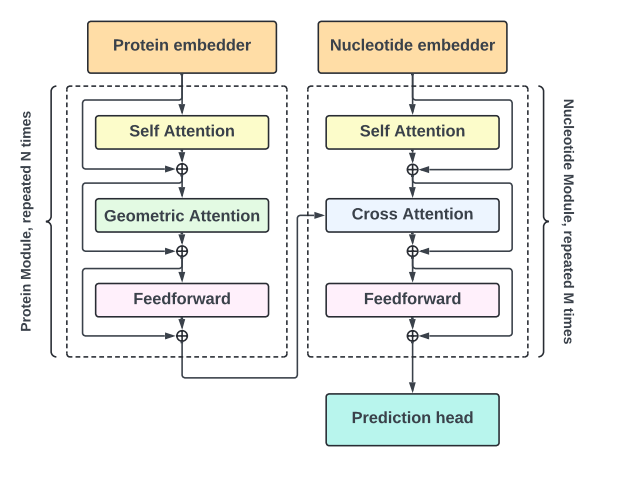

from RNA-BAnG paper  (without the geo attention cause would work first on 1d)


the self attention is already withing the esm2 and nuc transformer

order must be

nuc -- self-att --cross in (here you inject the info from the pro) -- ffn  -
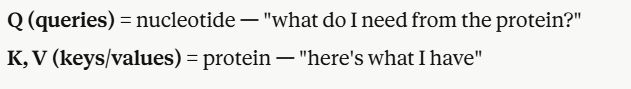
 cause the nuc is what is being generated

### the prot module
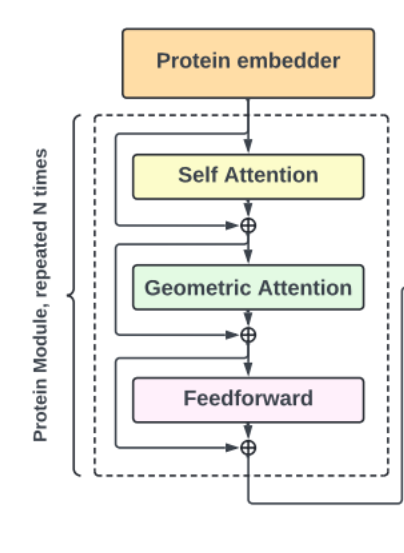

In [8]:
class ProteinModule(nn.Module):
    def __init__(self, prot_dim=1280, d_model=128, n_heads=4, n_layers=3, dropout=0.1):
        super().__init__()
        self.proj = nn.Sequential(
                    nn.Linear(prot_dim, d_model),
                    nn.LayerNorm(d_model),)
        
                #the self attention bloc
        self.blocks = nn.ModuleList([
                    nn.TransformerEncoderLayer(
                        d_model=d_model,
                        nhead=n_heads,
                        dim_feedforward=d_model * 4,
                        dropout=dropout,
                        batch_first=True,
                        activation="gelu",
                    )
                    for _ in range(n_layers)
                ])
    def forward(self, x, padding_mask=None):
        x = self.proj(x)
        for block in self.blocks:
            x = block(x, src_key_padding_mask=padding_mask)
        return x

## the nucmodule
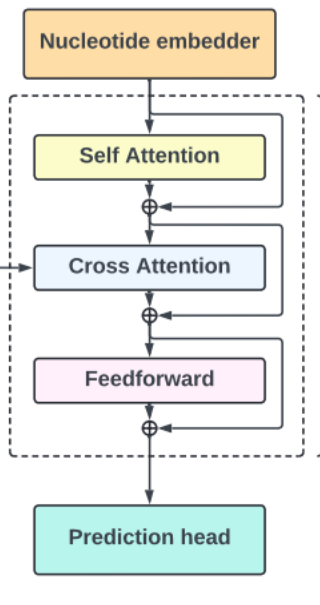

we have proj -- self att -- corss attention -- ffn

In [9]:
class NucleotideModule(nn.Module):
     def __init__(self, nuc_dim=1280, d_model=128, n_heads=4, n_layers=3, dropout=0.1):
         super().__init__()
         self.proj = nn.Sequential(
                    nn.Linear(nuc_dim, d_model),
                    nn.LayerNorm(d_model),)
        
                #the self attention bloc
         self.self_attn_blocks = nn.ModuleList([
            nn.TransformerEncoderLayer(d_model=d_model, nhead=n_heads,
                dim_feedforward=d_model*4, dropout=dropout,
                batch_first=True, activation="gelu")
            for _ in range(n_layers)
        ])
         self.cross_attn_blocks = nn.ModuleList([
            CrossAttentionLayer(d_model, n_heads, dropout)
            for _ in range(n_layers)
        ])
     def forward(self, nuc, prot, nuc_padding_mask=None, prot_padding_mask=None):
        nuc = self.proj(nuc)
        for self_attn, cross_attn in zip(self.self_attn_blocks, self.cross_attn_blocks):
            nuc = self_attn(nuc, src_key_padding_mask=nuc_padding_mask)
            nuc = cross_attn(nuc, prot, prot_key_padding_mask=prot_padding_mask)
        return nuc

## Full architecture

reads the protein and nuc moves then passes to the prjection head 


In [10]:
class FullArch(nn.Module):
    def __init__(self, dim=1280, d_model=128, n_heads=4, n_layers=3, dropout=0.1,vocab_size =None):
            super().__init__()
         
            self.protein_module=ProteinModule(dim,d_model,n_heads,n_layers,dropout)
            self.nuc_module=NucleotideModule(dim,d_model,n_heads,n_layers,dropout)
            self.head=nn.Linear(d_model , vocab_size )

    def forward(self, prot_hidden, nuc_hidden, prot_padding_mask=None, nuc_padding_mask=None):
        prot_repr = self.protein_module(prot_hidden, prot_padding_mask)
        nuc_repr  = self.nuc_module(nuc_hidden, prot_repr, nuc_padding_mask, prot_padding_mask)
        logits    = self.head(nuc_repr)
        return logits
    

## trying a forward pass with dummy data

In [11]:
# fake prot batch
prot_hidden = torch.randn(2, 50, 1280)  # batch=2, 50 residues
# fake nuc batch
nuc_hidden = torch.randn(2, 30, 1280)   # batch=2, 30 nucleotides

In [12]:
fn=FullArch(vocab_size=nuc_tokenizer.vocab_size)

In [13]:
testoutput=fn(prot_hidden,nuc_hidden)

In [14]:
print(testoutput.shape)

torch.Size([2, 30, 4107])


## masking approach
we hide x% of the apramer , and the model has to predict the nucletids from the 

### Maskign mecanims steps:
1) Function to maks x of the input == replace random toeksn with the mask toekn (index=2)
2) we pass the output of the functuon (masked input ids) through frozen nuctranformer to get nuc_hidden(for the masking %
   pipmlm worked on 100% masking so not sure if i follow that or work with sth less here :3)
4) pass prot_hidden + nuc_hidden through FullArch to get logits  (PS: the input protein , we work on 1d for now , work on dummy data , same as in nuc you are applying the masking on
5) compute loss : here the idea of constrasive loss can work because of the negative samples

In [15]:
#Step1
def mask_tokens(input_ids, mask_token_id, mask_prob=0.15):
    """
    Function to maks input on the nucl
    """
    labels = input_ids.clone()  # what we want to predict
    # create a random matrix, same shape as input_ids
    probability_matrix = torch.full(input_ids.shape, mask_prob)
    # random selection of x% of input to be masked aka replaced by mask toekn
    masked_positions = torch.bernoulli(probability_matrix).bool()
    # replace selected positions with MASK token
    masked_input_ids = input_ids.clone()
    masked_input_ids[masked_positions] = mask_token_id
    # we only compute loss on masked positions, ignore the rest
    labels[~masked_positions] = -100
    return masked_input_ids, labels

### for testing the forward pass i will not pass a 1d string "ATCUT" and get its tokens id i will just generate dummy toejns ids to test with for now

In [16]:
input_ids = torch.randint(0, 100, (2, 30))    #za nucleldites 

In [17]:
MASK_TOKEN_ID = nuc_tokenizer.mask_token_id
print(f"MASK token id: {MASK_TOKEN_ID}")  #again the id ofthe mask toejn for the nuc tokenizer

MASK token id: 2


In [18]:
masked_input_ids, labels=mask_tokens(input_ids, MASK_TOKEN_ID, mask_prob=0.15) #15% cause


In [19]:
print(masked_input_ids, labels)

tensor([[52, 14, 48,  2, 61, 92,  2, 25, 80, 96, 18, 75, 32, 31, 33, 36, 87, 42,
          7, 45, 41,  2, 82, 36, 86, 22, 92,  1, 93, 81],
        [42,  2, 90, 46, 89, 34, 20,  5, 57, 42,  9, 27, 50,  2,  1, 52, 78, 82,
          2, 35, 18,  2, 33, 91, 44, 35, 76, 56, 12, 74]]) tensor([[-100, -100, -100,   32, -100, -100,   98, -100, -100, -100, -100, -100,
         -100, -100, -100, -100, -100, -100, -100, -100, -100,    4, -100, -100,
         -100, -100, -100, -100, -100, -100],
        [-100,   51, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100,
         -100,   25, -100, -100, -100, -100,   41, -100, -100,    4, -100, -100,
         -100, -100, -100, -100, -100, -100]])


In [26]:
#step2 
nuc_encoder.cpu()
res=nuc_encoder(masked_input_ids,output_hidden_states=True)
nuc_hidden = res.hidden_states[-1]  # we take the last layer

In [23]:
print(res)

MaskedLMOutput(loss=None, logits=tensor([[[-14.7621, -13.4194, -12.0262,  ...,   3.3974,   3.2802,   2.7548],
         [-18.1201, -18.6087, -17.6767,  ...,   3.8659,   5.5380,   7.8395],
         [-18.8424, -20.7360, -18.1898,  ...,   5.9476,   6.8457,   9.2654],
         ...,
         [-17.2708, -18.5376, -15.6914,  ...,   4.8549,   6.2967,   8.5340],
         [-18.9432, -20.7319, -17.7020,  ...,   2.8739,   3.9945,   8.1940],
         [-19.3290, -20.2670, -17.9116,  ...,   1.3044,   2.9093,   5.4416]],

        [[-14.7834, -13.3321, -11.9513,  ...,   3.5586,   3.5601,   2.9284],
         [-17.0174, -17.0648, -16.3031,  ...,   5.0978,   5.5017,   6.8485],
         [-18.4103, -18.4050, -17.2996,  ...,   3.9059,   5.6581,   7.8281],
         ...,
         [-19.3498, -18.3778, -17.8154,  ...,   2.3782,   4.0886,   7.6283],
         [-18.4692, -20.1967, -17.5155,  ...,   5.5316,   6.7535,   8.7612],
         [-18.0511, -18.8493, -17.1970,  ...,   7.4431,   7.8898,   9.0080]]]), hidden_sta

In [27]:
print(nuc_hidden)

tensor([[[ 0.2357,  0.1075,  0.3340,  ..., -0.4408, -0.1194,  0.0255],
         [-0.3371,  1.1359, -0.1676,  ...,  0.3109,  0.6890, -1.1835],
         [ 0.0098,  0.5953, -0.5258,  ...,  0.7188,  0.8946, -1.1122],
         ...,
         [ 0.1115,  0.9423,  0.4055,  ...,  0.6105,  0.1893, -0.7637],
         [ 0.6861, -0.0157,  0.1109,  ..., -0.1439, -0.2301, -0.3151],
         [ 0.5517,  0.2218, -0.6259,  ..., -0.0943,  0.8276, -0.2361]],

        [[ 0.3244, -0.0442,  0.4933,  ..., -0.4872, -0.0479,  0.0266],
         [ 0.7594, -0.0386, -0.0771,  ..., -0.7256,  0.3593, -0.1643],
         [ 1.2013,  0.2034,  0.0492,  ..., -0.6022,  0.2500, -1.1174],
         ...,
         [ 0.4710,  0.8349, -0.1264,  ...,  0.0716, -0.3684, -0.6038],
         [ 0.9224,  0.1724, -0.5015,  ...,  0.3577, -0.3221, -0.1366],
         [ 1.0401,  0.3590,  0.0576,  ..., -0.0685,  0.2492, -0.3811]]])


In [30]:
prot_hidden = torch.randn(2, 50, 1280)  # new dummy data
logits = fn(prot_hidden, nuc_hidden)
print(logits.shape)

torch.Size([2, 30, 4107])


In [32]:
#step4 loss
#ps :your ground truth is the original token ids that you masked
loss = F.cross_entropy(
    logits.view(-1, logits.size(-1)),  #the modls predictiins
    labels.view(-1),  #your ground truth
    ignore_index=-100
)
print(loss)  #random value cause nothing is trained after all

tensor(8.2518, grad_fn=<NllLossBackward0>)


### Testing constrasive loss

In [ ]:
#in constrasive loss you need one vector per sequence , not per token like we have above in fullArch , 
#so this is a different version with pooling
class FullArch(nn.Module):
    def __init__(self, dim=1280, d_model=128, n_heads=4, n_layers=3, dropout=0.1,vocab_size =None):
            super().__init__()
         
            self.protein_module=ProteinModule(dim,d_model,n_heads,n_layers,dropout)
            self.nuc_module=NucleotideModule(dim,d_model,n_heads,n_layers,dropout)
            self.head=nn.Linear(d_model , vocab_size )

    def forward(self, prot_hidden, nuc_hidden, prot_padding_mask=None, nuc_padding_mask=None):
        prot_repr = self.protein_module(prot_hidden, prot_padding_mask)
        nuc_repr  = self.nuc_module(nuc_hidden, prot_repr, nuc_padding_mask, prot_padding_mask)
#need to aggregate all the info from all the tensors
        logits    = self.head(nuc_repr)
        return logits

